# LLM API

Ноутбук содержит примеры использования openai библиотеки для обращения к llm.

In [31]:
import os
import json
import numpy as np

from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel
from dataclasses import dataclass

In [32]:
def pprint(text):
    from IPython.display import display, Markdown
    display(Markdown(text))

1. Конфигурация LLM клиента:

    Для работы с LLM необходимо создать свой персональный `OPEN_ROUTER_API_KEY` и сохранить его в .env файл в корне проекта. Создать токен можно по [ссылке](https://openrouter.ai/settings/keys).

In [33]:
load_dotenv()

BASE_URL = "https://openrouter.ai/api/v1"
API_KEY = os.getenv("OPEN_ROUTER_API_KEY")
MODEL_NAME = "openai/gpt-4o-mini"
MODEL_PROVIDER="openrouter"

2. Создание LLM клиента:

In [34]:
client = OpenAI(base_url=BASE_URL, api_key=API_KEY)

3. Запрос к LLM модели с произвольным текстом:

In [35]:
response = client.responses.create(
    model=MODEL_NAME,
    input=[
        {"role": "user", "content": "Hello how are you?"}
    ]
)

pprint(response.output_text)

Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?

4. Запрос к LLM и получение результата как structured output:

In [36]:
dataclass
class GeneratorOutput(BaseModel):
    """Модель ответа"""
    sql: str


response = client.responses.parse(
    model=MODEL_NAME,
    input=[
        {"role": "system", "content": "Your are PostgreSQL generator AI agent. Answer with only sql."},
        {"role": "user", "content": "Find all records of users that are from IT and registered after some X variable"}
    ],
    text_format=GeneratorOutput
)

response.output_parsed

GeneratorOutput(sql="SELECT * FROM users WHERE department = 'IT' AND registration_date > X;")

5. Structured запрос и результат: 

In [37]:
dataclass
class GeneratorInput(BaseModel):
    """Модель запроса"""
    user_text: str


input = GeneratorInput(
    user_text="Find all records of users that are from IT and registered after some X variable"
)

print("Request:")
print(input.model_dump_json())

response = client.responses.parse(
    model=MODEL_NAME,
    input=[
        {"role": "system", "content": "Your are PostgreSQL generator AI agent. Answer with only sql."},
        {"role": "user", "content": input.model_dump_json()}
    ],
    text_format=GeneratorOutput
)

response.output_parsed

Request:
{"user_text":"Find all records of users that are from IT and registered after some X variable"}


GeneratorOutput(sql="SELECT * FROM users WHERE department = 'IT' AND registration_date > X;")

6. Простейший RAG с поиском по тексту с использованием embeddings:

In [38]:
# Пример документа, поиск по которому мы хотим добавить:
docs = [
    "OpenAI API позволяет использовать модели через HTTP.",
    "RAG объединяет поиск и генерацию текста.",
    "RAG полезен при решении SQL audit.",
    "LLM не хранит актуальные данные сама по себе."
]

def embed(text):
    return client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    ).data[0].embedding

# Строим для текста embedding
doc_embeddings = [embed(d) for d in docs]

def cosine(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def retrieve(query, k=2):
    """Функция поиска по тексту"""
    q_emb = embed(query)

    scores = [(i, cosine(q_emb, doc_embeddings[i])) for i in range(len(docs))]
    scores.sort(key=lambda x: x[1], reverse=True)

    return [docs[i] for i, _ in scores[:k]]

In [39]:
# Описание инструмента: что принимает на вход и выход.
tools = [
    {
        "type": "function",
        "function": {
            "name": "retrieve",
            "description": "Search relevant documents",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {
                        "type": "string"
                    }
                },
                "required": ["query"]
            }
        }   
    }
]

input_list = [
    {"role": "user", "content": "Где используется RAG? Ответь коротко"}
]

def get_response(use_tool=False):
    instruction = "You are agent."
    if use_tool:
        instruction += "Use tools at least one time."
    else:
        instruction += "Give answer. After tool result, you MUST produce final answer and STOP. Do not call any tools again."

    return client.chat.completions.create(
        messages=input_list,
        model=MODEL_NAME,
        tools=tools
    )

response = get_response(use_tool=True)

In [40]:
message = response.choices[0].message

if message.tool_calls:
    input_list.append(message)

    for call in message.tool_calls:
        if call.function.name == "retrieve":
            query = json.loads(call.function.arguments)["query"]
            result = retrieve(query)
            print("Call tool result:", result)

            input_list.append({
                "role": "tool",
                "tool_call_id": call.id,
                "content": "\n".join(result)
            })

Call tool result: ['RAG полезен при решении SQL audit.', 'RAG объединяет поиск и генерацию текста.']


In [41]:
response = get_response()

In [42]:
pprint(response.choices[0].message.content)

RAG (Retrieval-Augmented Generation) используется в задачах, связанных с SQL-аудитом, а также для объединения поиска и генерации текста.

7. LangChain для создания агента:

LangChain под капотом создает run loop, делает повторные запросы к LLM для выполнения тулзов, упрощает создание агента.

In [43]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_core.globals import set_debug
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI

In [44]:
@tool
def search_doc(query: str) -> str:
    """
    Search relevant documents
    """
    print("Call search doc tool")
    return retrieve(query)


set_debug(True)
os.environ["OPENROUTER_API_KEY"] = os.getenv("OPEN_ROUTER_API_KEY")

system_prompt="""
Ты AI ассестент, отвечай на вопросы пользователя.
"""

llm = ChatOpenAI(
    base_url=BASE_URL,
    api_key=API_KEY,
    model=MODEL_NAME
)

In [45]:
agent = create_agent(
    model=llm,
    system_prompt=system_prompt,
    tools=[search_doc]
)

messages = [
    HumanMessage("Где используется RAG?")
]

response = agent.invoke(
    input={ "messages": messages }
)

print(response)

[chain/start] [chain:LangGraph] Entering Chain run with input:
[inputs]
[chain/start] [chain:LangGraph > chain:model] Entering Chain run with input:
[inputs]
[llm/start] [chain:LangGraph > chain:model > llm:ChatOpenAI] Entering LLM run with input:
{
  "prompts": [
    "System: \nТы AI ассестент, отвечай на вопросы пользователя.\n\nHuman: Где используется RAG?"
  ]
}


Error in ConsoleCallbackHandler.on_tool_start callback: KeyError('input')


[llm/end] [chain:LangGraph > chain:model > llm:ChatOpenAI] [1.68s] Exiting LLM run with output:
{
  "generations": [
    [
      {
        "text": "",
        "generation_info": {
          "finish_reason": "tool_calls",
          "logprobs": null
        },
        "type": "ChatGeneration",
        "message": {
          "lc": 1,
          "type": "constructor",
          "id": [
            "langchain",
            "schema",
            "messages",
            "AIMessage"
          ],
          "kwargs": {
            "content": "",
            "additional_kwargs": {
              "refusal": null
            },
            "response_metadata": {
              "token_usage": {
                "completion_tokens": 18,
                "prompt_tokens": 60,
                "total_tokens": 78,
                "completion_tokens_details": {
                  "accepted_prediction_tokens": null,
                  "audio_tokens": 0,
                  "reasoning_tokens": 0,
                  "r

In [46]:
text = response["messages"][-1].content
pprint(text)

RAG (Retrieval-Augmented Generation) используется в разных областях, включая:

1. **SQL аудит** - RAG помогает в анализе и проверке SQL запросов.
2. **Объединение поиска и генерации текста** - Эта технология совмещает возможности поиска информации и генерации текста, что позволяет создавать более контекстуально релевантные ответы. 

Если вас интересуют другие применения или детали, дайте знать!

8. LangGraph для создания мультиагентного графа:

In [65]:
import logging

from typing_extensions import TypedDict, Annotated, Literal

from langchain.messages import AnyMessage, AIMessage
from langchain_core.runnables.passthrough import RunnablePassthrough

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from pydantic import BaseModel, Field

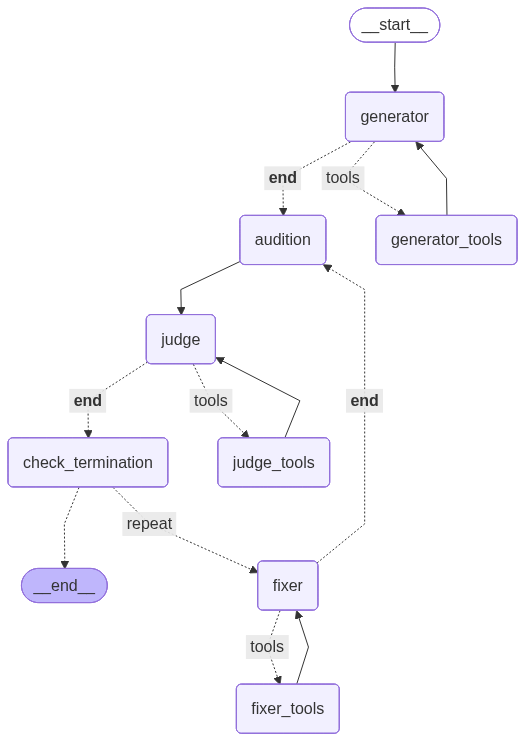

In [75]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger("audit_system")


class FoundIssue(BaseModel):
    type: str
    severity: Literal["LOW", "MEDIUM", "HIGH"]
    message: str = Field(description="Short human readable issue description")
    fix_instruction: str = Field(description="Direct instruction of what need to be resolved")


class JudgeOutput(BaseModel):
    verdict: Literal["APPROVED", "REJECTED"]
    issues: list[FoundIssue]


class GeneratorOutput(BaseModel):
    sql: str = Field(description="generated sql request")


class FixerOutput(BaseModel):
    sql: str = Field(description="fixed sql request")


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    judge_responses: list[JudgeOutput]
    llm_calls: int
    audit_iteration: int


def call_generator(state: dict):
    logger.info("Call generator agent")

    system_message = SystemMessage(content="Your are PostgreSQL generator AI agent. Answer with only sql.")

    messages = [system_message] + state["messages"]
    response = llm.with_structured_output(GeneratorOutput).invoke(messages)

    return {
        "messages": [AIMessage(content=str(response.model_dump_json(indent=4)))],
        "llm_calls": state.get('llm_calls', 0) + 1,
    }


def start_audition(state: dict):
    iteration = state.get("audit_iteration")
    if iteration is None:
        iteration = 0
    else: 
        iteration += 1

    logger.info(f"Start audition: {iteration}")

    return {
        "audit_iteration": iteration
    }


def call_judge(state: dict):
    logger.info("Call judge agent")

    system_message = SystemMessage(content="Your are PostgreSQL auditor AI agent. Read input SQL and create list of issues and make verdict approved or rejected.")

    messages = [system_message] + state["messages"]
    response = llm.with_structured_output(JudgeOutput).invoke(messages)

    return {
        "messages": [AIMessage(content=response.model_dump_json(indent=4))],
        "llm_calls": state.get('llm_calls', 0) + 1,
        "judge_responses": state.get("judge_responses", []) + [response]
    }


def call_fixer(state: dict):
    logger.info("Call fixer agent")

    system_message = SystemMessage(content="Your are PostgreSQL fixer, read input SQL resolve issues and respond with corrected only sql.")

    messages = [system_message] + state["messages"]
    response = llm.with_structured_output(FixerOutput).invoke(messages)

    return {
        "messages": [AIMessage(content=response.model_dump_json(indent=4))],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

def check_termination_condition(state: dict):
    judge_response: JudgeOutput = state["judge_responses"][-1]
    iteration = state.get("audit_iteration", 0)    

    if judge_response.verdict == "APPROVED":
        logger.info("Terminate with approve")
        return END

    if iteration >= 3:
        logger.info("Terminate by number of iterations exceeded")
        return END

    logger.info("Go next iteration")

    return "repeat"


agent_builder = StateGraph(MessagesState)

# Nodes
agent_builder.add_node("generator", call_generator)
agent_builder.add_node("audition", start_audition)
agent_builder.add_node("judge", call_judge)
agent_builder.add_node("fixer", call_fixer)
agent_builder.add_node("check_termination", RunnablePassthrough())

# Tools
agent_builder.add_node("generator_tools", ToolNode([search_doc]))
agent_builder.add_node("judge_tools", ToolNode([search_doc]))
agent_builder.add_node("fixer_tools", ToolNode([search_doc]))

# Generator
agent_builder.add_edge(START, "generator")
agent_builder.add_conditional_edges("generator", tools_condition, {"tools": "generator_tools", END: "audition"})
agent_builder.add_edge("generator_tools", "generator")

# Audition
agent_builder.add_edge("audition", "judge")

# Judge
agent_builder.add_conditional_edges("judge", tools_condition, {"tools": "judge_tools", END: "check_termination"})
agent_builder.add_edge("judge_tools", "judge")

# Analyze epoch
agent_builder.add_conditional_edges("check_termination", check_termination_condition, {"repeat": "fixer", END: END})

# Fixer
agent_builder.add_conditional_edges("fixer", tools_condition, {"tools": "fixer_tools", END: "audition"})
agent_builder.add_edge("fixer_tools", "fixer")

agent = agent_builder.compile()

from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [76]:
messages = [HumanMessage("Find all records of users that are from IT and registered after some X variable")]
set_debug(False)

response = agent.invoke({"messages": messages})

2026-05-10 03:40:50,139 - audit_system - INFO - Call generator agent
2026-05-10 03:40:51,564 - httpx - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 03:40:51,813 - audit_system - INFO - Start audition: 0
2026-05-10 03:40:51,813 - audit_system - INFO - Call judge agent
2026-05-10 03:40:52,760 - httpx - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 03:40:53,539 - audit_system - INFO - Go next iteration
2026-05-10 03:40:53,540 - audit_system - INFO - Call fixer agent
2026-05-10 03:40:54,441 - httpx - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 03:40:54,845 - audit_system - INFO - Start audition: 1
2026-05-10 03:40:54,845 - audit_system - INFO - Call judge agent
2026-05-10 03:40:55,752 - httpx - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 03:40:56,046 - audit_system - I

In [77]:
def print_response(resp):
    pprint("# History")
    for i, message in enumerate(resp["messages"]):
        pprint(f"### {i + 1}")
        print(f"{message.content}")


print_response(response)

# History

### 1

Find all records of users that are from IT and registered after some X variable


### 2

{
    "sql": "SELECT * FROM users WHERE department = 'IT' AND registration_date > X;"
}


...

{
    "verdict": "REJECTED",
    "issues": [
        {
            "type": "SQL_SYNTAX",
            "severity": "HIGH",
            "message": "Parameter X is not valid SQL syntax. The variable should be defined correctly or passed using parameterized queries.",
            "fix_instruction": "Replace 'X' with a valid date format or use a parameterized query to define the variable."
        }
    ]
}


### 4

{
    "sql": "SELECT * FROM users WHERE department = 'IT' AND registration_date > '2023-01-01';"
}


### 5

{
    "verdict": "APPROVED",
    "issues": []
}
